In [71]:
bhk,n_baths,n_balconies = [],[],[]
prices=[]
developer=[]
projects=[]
carpet_area=[]
locality=[]
city_list=[]
emi=[]

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

def setup_driver():
    options = Options()
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)
    options.add_argument('--window-size=1280,800')
    options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36')
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    return driver


# ── STEP 1: Collect project page links by scrolling ──────────────────
def get_project_links(city_name, target=20):
    """Scroll listing page, collect -pdpid- project links"""
    driver = setup_driver()
    project_links = []

    try:
        driver.get(
            f'https://www.magicbricks.com/property-for-sale/residential-real-estate'
            f'?proptype=Multistorey-Apartment&cityName={city_name}'
        )
        time.sleep(6)
        no_new = 0

        while len(project_links) < target:
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            for a in soup.find_all('a', href=True):
                href = a['href']
                if 'pdpid' in href and href not in project_links:
                    project_links.append(href)

            print(f"  [{city_name}] Project links: {len(project_links)}/{target}")

            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(4)

            new_count = len(project_links)
            if new_count == len(project_links):
                no_new += 1
                if no_new >= 3:
                    break
            else:
                no_new = 0

    finally:
        driver.quit()

    return list(dict.fromkeys(project_links))[:target]  # deduplicate


# ── STEP 2: Visit each project page, get individual property links ────
def get_property_links_from_project(driver, project_url):
    """Each project page lists individual units with propertyDetails links"""
    property_links = []
    try:
        driver.get(project_url)
        time.sleep(4)
        soup = BeautifulSoup(driver.page_source, 'html.parser')

        for a in soup.find_all('a', href=True):
            href = a['href']
            if 'propertyDetails' in href and 'campaign' not in href:
                if not href.startswith('http'):
                    href = 'https://www.magicbricks.com' + href
                if href not in property_links:
                    property_links.append(href)

        print(f"    Project: {project_url[-50:]} → {len(property_links)} units")
    except Exception as e:
        print(f"    Error: {e}")

    return property_links


# ── STEP 3: Run everything ────────────────────────────────────────────
cities = {
    'Hyderabad': '2060',
    'Mumbai':    '4320',
    'Bangalore': '3327',
    'Ahmedabad': '2690',
    'Delhi-NCR': '509',
    'Noida': '6403',
    'Gurgaon':'2951',
}

all_links = {}

for city_name in cities:
    print(f"\n{'='*50}")
    print(f"City: {city_name}")

    # Step 1
    print(f"  Step 1: Collecting project pages...")
    project_links = get_project_links(city_name, target=20)
    print(f"  Got {len(project_links)} project pages")

    # Step 2
    print(f"  Step 2: Extracting individual property links...")
    city_property_links = []
    driver = setup_driver()
    try:
        for proj_url in project_links:
            links = get_property_links_from_project(driver, proj_url)
            city_property_links.extend(links)
            if len(city_property_links) >= 100:
                break
            time.sleep(2)
    finally:
        driver.quit()

    all_links[city_name] = city_property_links[:100]
    print(f"✅ {city_name}: {len(all_links[city_name])} property links")

print("\n── Summary ──────────────────────────")
for city, links in all_links.items():
    print(f"  {city}: {len(links)} links")
print(f"  Total: {sum(len(v) for v in all_links.values())} links")

import numpy as np
import time

for city_name, links in all_links.items():
    for url in links:
        try:
            page = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(page.text, 'html.parser')

            try:
                bhk.append(soup.find_all('span', class_='mb-ldp__dtls__body__summary--highlight')[0].text.strip())
            except:
                bhk.append(np.nan)

            try:
                n_baths.append(soup.find_all('span', class_='mb-ldp__dtls__body__summary--highlight')[1].text.strip())
            except:
                n_baths.append(np.nan)

            try:
                n_balconies.append(soup.find_all('span', class_='mb-ldp__dtls__body__summary--highlight')[2].text.strip())
            except:
                n_balconies.append(np.nan)

            try:
                prices.append(soup.find_all('div', class_='mb-ldp__dtls__price')[0].text.strip())
            except:
                prices.append(np.nan)

            try:
                developer.append(soup.find_all('a', class_='mb-ldp__dtls__body__list--link')[0].text.strip())
            except:
                developer.append(np.nan)

            try:
                projects.append(soup.find_all('a', class_='mb-ldp__dtls__body__list--link')[1].text.strip())
            except:
                projects.append(np.nan)

            try:
                carpet_area.append(soup.find_all('div', class_='mb-ldp__dtls__body__list')[0].text.split('sqft')[0].strip())
            except:
                carpet_area.append(np.nan)

            # ── Locality & City — ONE append per property ────────
            try:
                feature = soup.find_all('a', class_='mb-ldp__dtls__title--link')[0]
                text = feature.text.strip()
                parts = text.split(',')
                locality.append(parts[0].strip() if len(parts) > 0 else np.nan)
                city_list.append(parts[1].strip() if len(parts) > 1 else np.nan)
            except:
                locality.append(np.nan)
                city_list.append(np.nan)

            # ── EMI — ONE append per property ────────────────────
            try:
                feature = soup.find_all('a', class_='mb-ldp__dtls__applyLoan')[0]
                raw = feature.text
                emi_val = raw.split('₹ ')[1].strip() if '₹ ' in raw else np.nan
                emi.append(emi_val)
            except:
                emi.append(np.nan)

            time.sleep(1)

        except requests.exceptions.Timeout:
            print(f"  ⏱ Timeout: {url}")
            bhk.append(np.nan); n_baths.append(np.nan); n_balconies.append(np.nan)
            prices.append(np.nan); developer.append(np.nan); projects.append(np.nan)
            carpet_area.append(np.nan); locality.append(np.nan)
            city_list.append(np.nan); emi.append(np.nan)

        except requests.exceptions.ConnectionError:
            print(f"  🔌 Connection error: {url}")
            bhk.append(np.nan); n_baths.append(np.nan); n_balconies.append(np.nan)
            prices.append(np.nan); developer.append(np.nan); projects.append(np.nan)
            carpet_area.append(np.nan); locality.append(np.nan)
            city_list.append(np.nan); emi.append(np.nan)

        except Exception as e:
            print(f"  ❌ Error on {url}: {e}")
            bhk.append(np.nan); n_baths.append(np.nan); n_balconies.append(np.nan)
            prices.append(np.nan); developer.append(np.nan); projects.append(np.nan)
            carpet_area.append(np.nan); locality.append(np.nan)
            city_list.append(np.nan); emi.append(np.nan)

# ── Safe DataFrame creation ───────────────────────────────────────────
lengths = {
    'bhk': len(bhk), 'n_baths': len(n_baths), 'n_balconies': len(n_balconies),
    'prices': len(prices), 'developer': len(developer), 'projects': len(projects),
    'carpet_area': len(carpet_area), 'locality': len(locality),
    'city_list': len(city_list), 'emi': len(emi)
}
print("Array lengths:", lengths)  # all must be equal




City: Hyderabad
  Step 1: Collecting project pages...
  [Hyderabad] Project links: 33/20
  Got 20 project pages
  Step 2: Extracting individual property links...
    Project: hony-patancheru-hyderabad-pdpid-4d4235333236383833 → 10 units
    Project: -rajendra-nagar-hyderabad-pdpid-4d4235343138323731 → 10 units
    Project: nate-patancheru-hyderabad-pdpid-4d4235333137303339 → 10 units
    Project: ront-somajiguda-hyderabad-pdpid-4d4235333838343931 → 10 units
    Project: -rajendra-nagar-hyderabad-pdpid-4d4235343335303635 → 10 units
    Project: ivasam-kondapur-hyderabad-pdpid-4d4235333333363337 → 10 units
    Project: -altus-narsingi-hyderabad-pdpid-4d4235343435393933 → 7 units
    Project: sierra-tellapur-hyderabad-pdpid-4d4235343337323339 → 10 units
    Project: d-33-bachupally-hyderabad-pdpid-4d4235333234333131 → 10 units
    Project: eopolis-kokapet-hyderabad-pdpid-4d4235343333353133 → 10 units
    Project: st-hastinapuram-hyderabad-pdpid-4d4235343234343133 → 8 units
✅ Hyderabad: 1

In [192]:
df = pd.DataFrame({
    'BHK':          bhk,
    'Bathrooms':    n_baths,
    'Balconies':    n_balconies,
    'Price':        prices,
    'Developer':    developer,
    'Project':      projects,
    'Carpet Area':  carpet_area,
    'Locality':     locality,
    'City':         city_list,
    'EMI':          emi
})

print(df.shape)
print(df.head())

(700, 10)
   BHK Bathrooms Balconies           Price                      Developer  \
0    3         2         1       ₹97.4 Lac  Ramky Estates & Farms Limited   
1    2         2                 ₹85.0 Lac  Ramky Estates & Farms Limited   
2    3         2         1        ₹1.22 Cr  Ramky Estates & Farms Limited   
3    2         2         1       ₹90.0 Lac  Ramky Estates & Farms Limited   
4  NaN       NaN       NaN  Call for Price  Ramky Estates & Farms Limited   

              Project Carpet Area    Locality       City  EMI  
0  Ramky One Symphony        1265  Patancheru  Hyderabad  34k  
1  Ramky One Symphony        1065  Patancheru  Hyderabad  29k  
2  Ramky One Symphony        1585  Patancheru  Hyderabad  42k  
3  Ramky One Symphony         674  Patancheru  Hyderabad  31k  
4  Ramky One Symphony         NaN  Patancheru  Hyderabad    0  


In [226]:
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3,2,1,₹97.4 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1265,Patancheru,Hyderabad,34k
1,2,2,,₹85.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1065,Patancheru,Hyderabad,29k
2,3,2,1,₹1.22 Cr,Ramky Estates & Farms Limited,Ramky One Symphony,1585,Patancheru,Hyderabad,42k
3,2,2,1,₹90.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,674,Patancheru,Hyderabad,31k
4,NaN,NaN,NaN,Call for Price,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,0
...,...,...,...,...,...,...,...,...,...,...
695,4,4,4,₹6.45 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.23L
696,4,4,4,₹6.65 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.30L
697,5,5,3,₹8.67 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500,Sector 106,Gurgaon,3.00L
698,NaN,NaN,NaN,₹8.39 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700,Sector 106,Gurgaon,2.91L


# Start or Run only from here(don't touch any of the above code)

## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('MagicBrick_Data.csv')
df

,Unnamed: 0,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,0,3.0,2.0,1.0,₹97.4 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1265,Patancheru,Hyderabad,34k
1,1,2.0,2.0,NaN,₹85.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1065,Patancheru,Hyderabad,29k
2,2,3.0,2.0,1.0,₹1.22 Cr,Ramky Estates & Farms Limited,Ramky One Symphony,1585,Patancheru,Hyderabad,42k
3,3,2.0,2.0,1.0,₹90.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,674,Patancheru,Hyderabad,31k
4,4,NaN,NaN,NaN,Call for Price,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,0
...,...,...,...,...,...,...,...,...,...,...,...
695,695,4.0,4.0,4.0,₹6.45 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.23L
696,696,4.0,4.0,4.0,₹6.65 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.30L
697,697,5.0,5.0,3.0,₹8.67 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500,Sector 106,Gurgaon,3.00L
698,698,NaN,NaN,NaN,₹8.39 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700,Sector 106,Gurgaon,2.91L


In [4]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3.0,2.0,1.0,₹97.4 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1265,Patancheru,Hyderabad,34k
1,2.0,2.0,NaN,₹85.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,1065,Patancheru,Hyderabad,29k
2,3.0,2.0,1.0,₹1.22 Cr,Ramky Estates & Farms Limited,Ramky One Symphony,1585,Patancheru,Hyderabad,42k
3,2.0,2.0,1.0,₹90.0 Lac,Ramky Estates & Farms Limited,Ramky One Symphony,674,Patancheru,Hyderabad,31k
4,NaN,NaN,NaN,Call for Price,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,0
...,...,...,...,...,...,...,...,...,...,...
695,4.0,4.0,4.0,₹6.45 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.23L
696,4.0,4.0,4.0,₹6.65 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702,Sector 106,Gurgaon,2.30L
697,5.0,5.0,3.0,₹8.67 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500,Sector 106,Gurgaon,3.00L
698,NaN,NaN,NaN,₹8.39 Cr,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700,Sector 106,Gurgaon,2.91L


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BHK          675 non-null    float64
 1   Bathrooms    675 non-null    float64
 2   Balconies    650 non-null    float64
 3   Price        698 non-null    object 
 4   Developer    692 non-null    object 
 5   Project      670 non-null    object 
 6   Carpet Area  697 non-null    object 
 7   Locality     698 non-null    object 
 8   City         698 non-null    object 
 9   EMI          698 non-null    object 
dtypes: float64(3), object(7)
memory usage: 54.8+ KB


# Converting Price, Carpet Area, EMI columns from object to float64 Dtype

### Price column

In [7]:
## convert Price,Carpet Area,EMI columns to numerical

df['Price']

for i in range(len(df['Price'])):
    if '₹' in str(df.at[i,'Price']).strip():
        df.at[i,'Price']=df.at[i,'Price'].replace('₹','').strip()
    else:
        df.at[i,'Price']=np.nan


In [8]:
df['Price']

0      97.4 Lac
1      85.0 Lac
2       1.22 Cr
3      90.0 Lac
4           NaN
         ...   
695     6.45 Cr
696     6.65 Cr
697     8.67 Cr
698     8.39 Cr
699      5.0 Cr
Name: Price, Length: 700, dtype: object

In [9]:
df['Price'].unique()

array(['97.4 Lac', '85.0 Lac', '1.22 Cr', '90.0 Lac', nan, '89.5 Lac',
       '69.0 Lac', '1.30 Cr', '75.0 Lac', '1.50 Cr', '1.64 Cr', '1.87 Cr',
       '1.65 Cr', '2.58 Cr', '1.19 Cr', '1.55 Cr', '2.0 Cr', '3.10 Cr',
       '1.14 Cr', '80.2 Lac', '79.6 Lac', '82.5 Lac', '76.4 Lac',
       '1.10 Cr', '82.2 Lac', '98.0 Lac', '3.0 Cr', '3.70 Cr', '4.18 Cr',
       '2.81 Cr', '4.50 Cr', '3.76 Cr', '4.27 Cr', '3.81 Cr', '2.98 Cr',
       '1.40 Cr', '1.56 Cr', '2.43 Cr', '1.46 Cr', '2.23 Cr', '1.68 Cr',
       '1.80 Cr', '1.94 Cr', '1.71 Cr', '2.17 Cr', '1.85 Cr', '2.16 Cr',
       '1.95 Cr', '2.21 Cr', '2.20 Cr', '2.24 Cr', '1.97 Cr', '1.33 Cr',
       '1.69 Cr', '93.2 Lac', '1.20 Cr', '95.0 Lac', '1.18 Cr', '1.25 Cr',
       '1.05 Cr', '1.02 Cr', '1.45 Cr', '3.74 Cr', '4.76 Cr', '4.78 Cr',
       '3.72 Cr', '3.73 Cr', '4.28 Cr', '88.0 Lac', '9.10 Cr', '24.05 Cr',
       '9.81 Cr', '23.72 Cr', '12.15 Cr', '11.58 Cr', '8.57 Cr',
       '12.10 Cr', '18.20 Cr', '3.95 Cr', '4.12 Cr', '2.10 Cr'

In [10]:
for i in range(len(df['Price'])):
    if 'Cr' in str(df.at[i,'Price']).strip():
        df.at[i,'Price']=df.at[i,'Price'].replace('Cr','').strip()
        df.at[i,'Price']=float(df.at[i,'Price'])*10000000
    elif 'Lac' in str(df.at[i,'Price']).strip():
        df.at[i,'Price']=df.at[i,'Price'].replace('Lac','').strip()
        df.at[i,'Price']=float(df.at[i,'Price'])*100000
    else:
        df.at[i,'Price']=np.nan

In [11]:
df['Price']=df["Price"].astype('float64')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BHK          675 non-null    float64
 1   Bathrooms    675 non-null    float64
 2   Balconies    650 non-null    float64
 3   Price        677 non-null    float64
 4   Developer    692 non-null    object 
 5   Project      670 non-null    object 
 6   Carpet Area  697 non-null    object 
 7   Locality     698 non-null    object 
 8   City         698 non-null    object 
 9   EMI          698 non-null    object 
dtypes: float64(4), object(6)
memory usage: 54.8+ KB


### EMI column

In [13]:
df['EMI']

0        34k
1        29k
2        42k
3        31k
4          0
       ...  
695    2.23L
696    2.30L
697    3.00L
698    2.91L
699    1.73L
Name: EMI, Length: 700, dtype: object

In [14]:
for i in range(len(df['EMI'])):
    if 'k' in str(df.at[i,'EMI']).strip():
        df.at[i,'EMI']=df.at[i,'EMI'].replace('k','').strip()
        df.at[i,'EMI']=float(df.at[i,'EMI'])*1000
    elif 'L' in str(df.at[i,'EMI']).strip():
        df.at[i,'EMI']=df.at[i,'EMI'].replace('L','').strip()
        df.at[i,'EMI']=float(df.at[i,'EMI'])*100000
    else:
        df.at[i,'EMI']=np.nan

In [15]:
df['EMI']

0       34000.0
1       29000.0
2       42000.0
3       31000.0
4           NaN
         ...   
695    223000.0
696    230000.0
697    300000.0
698    291000.0
699    173000.0
Name: EMI, Length: 700, dtype: object

In [16]:
df['EMI']=df['EMI'].astype('float64')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   BHK          675 non-null    float64
 1   Bathrooms    675 non-null    float64
 2   Balconies    650 non-null    float64
 3   Price        677 non-null    float64
 4   Developer    692 non-null    object 
 5   Project      670 non-null    object 
 6   Carpet Area  697 non-null    object 
 7   Locality     698 non-null    object 
 8   City         698 non-null    object 
 9   EMI          696 non-null    float64
dtypes: float64(5), object(5)
memory usage: 54.8+ KB


### Carpet Area Column

In [18]:
df['Carpet Area']

0      1265
1      1065
2      1585
3       674
4       NaN
       ... 
695    1702
696    1702
697    2500
698    2700
699    1159
Name: Carpet Area, Length: 700, dtype: object

In [19]:
df['Carpet Area'].unique()

array(['1265', '1065', '1585', '674', nan, '1063', '1687', '1079', '2433',
       '1223', '3357', '1534', '1548', '1994', '1394', '1384', '1434',
       '1328', '1923', '1428', '1921', '1704', '1345', '2188', '2690',
       '3045', '2044', '3278', '2740', '3111', '2770', '3571', '1679',
       '1873', '2904', '2673', '2016', '2025', '1368', '1740', '2270',
       '1915', '1787', '2445', '2700', '2765', '2750', '2800', '2440',
       '2465', '1850', '1295', '2350', '2555', '1353', '1110', '940',
       '1400', '685', '900', '750', '1617', '3390', '2655', '4330',
       '3895', '1355', '1825', '1755', '3700', '1531', '3650', '1845',
       '1899', '1406', '1152', '1146', '700', '618', '669', '645', '691',
       '680', '1145', '970', '1200', '1198', '1131', '932', '1303', '855',
       '1700', '1007', '761', '1255', '1218', '1009', '701', '647',
       '1026', '620', '1140', '1045', '695', '624', '1100', '602', '447',
       '400', '650', '912', '720', '2798', '3108', '2364', '2777', '22

In [20]:
for i in range(len(df['Carpet Area'])):
    val = str(df.at[i, 'Carpet Area']).lower().replace(',', '').strip()
    
    if val == 'nan':
        continue
    
    elif val.replace('.', '').isdigit():   # handles floats too
        df.at[i, 'Carpet Area'] = float(val)
    
    elif 'sqm' in val:
        num = val.replace('sqm', '').strip()
        df.at[i, 'Carpet Area'] = float(num) * 10.7639
    
    elif 'sqyrd' in val:
        num = val.replace('sqyrd', '').strip()
        df.at[i, 'Carpet Area'] = float(num) * 9
    
    else:
        df.at[i, 'Carpet Area'] = np.nan

In [21]:
df['Carpet Area']

0      1265.0
1      1065.0
2      1585.0
3       674.0
4         NaN
        ...  
695    1702.0
696    1702.0
697    2500.0
698    2700.0
699    1159.0
Name: Carpet Area, Length: 700, dtype: object

In [22]:
df['Carpet Area']=df['Carpet Area'].astype('float64')
df['Carpet Area'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 700 entries, 0 to 699
Series name: Carpet Area
Non-Null Count  Dtype  
--------------  -----  
697 non-null    float64
dtypes: float64(1)
memory usage: 5.6 KB


In [23]:
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3.0,2.0,1.0,9740000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1265.0,Patancheru,Hyderabad,34000.0
1,2.0,2.0,NaN,8500000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1065.0,Patancheru,Hyderabad,29000.0
2,3.0,2.0,1.0,12200000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1585.0,Patancheru,Hyderabad,42000.0
3,2.0,2.0,1.0,9000000.0,Ramky Estates & Farms Limited,Ramky One Symphony,674.0,Patancheru,Hyderabad,31000.0
4,NaN,NaN,NaN,NaN,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,NaN
...,...,...,...,...,...,...,...,...,...,...
695,4.0,4.0,4.0,64500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,223000.0
696,4.0,4.0,4.0,66500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,230000.0
697,5.0,5.0,3.0,86700000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500.0,Sector 106,Gurgaon,300000.0
698,NaN,NaN,NaN,83900000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,291000.0


# Drop missing values and duplicates of object type columns and BHK, Bathrooms and Balconies columns

In [24]:
df.select_dtypes(include='object').isna().sum()

Developer     8
Project      30
Locality      2
City          2
dtype: int64

In [25]:
obj_cols = df.select_dtypes(include='object').columns
df = df.dropna(subset=obj_cols)
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3.0,2.0,1.0,9740000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1265.0,Patancheru,Hyderabad,34000.0
1,2.0,2.0,NaN,8500000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1065.0,Patancheru,Hyderabad,29000.0
2,3.0,2.0,1.0,12200000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1585.0,Patancheru,Hyderabad,42000.0
3,2.0,2.0,1.0,9000000.0,Ramky Estates & Farms Limited,Ramky One Symphony,674.0,Patancheru,Hyderabad,31000.0
4,NaN,NaN,NaN,NaN,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,NaN
...,...,...,...,...,...,...,...,...,...,...
695,4.0,4.0,4.0,64500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,223000.0
696,4.0,4.0,4.0,66500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,230000.0
697,5.0,5.0,3.0,86700000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500.0,Sector 106,Gurgaon,300000.0
698,NaN,NaN,NaN,83900000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,291000.0


In [26]:
df.duplicated(keep=False).sum()

np.int64(162)

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3.0,2.0,1.0,9740000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1265.0,Patancheru,Hyderabad,34000.0
1,2.0,2.0,NaN,8500000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1065.0,Patancheru,Hyderabad,29000.0
2,3.0,2.0,1.0,12200000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1585.0,Patancheru,Hyderabad,42000.0
3,2.0,2.0,1.0,9000000.0,Ramky Estates & Farms Limited,Ramky One Symphony,674.0,Patancheru,Hyderabad,31000.0
4,NaN,NaN,NaN,NaN,Ramky Estates & Farms Limited,Ramky One Symphony,NaN,Patancheru,Hyderabad,NaN
...,...,...,...,...,...,...,...,...,...,...
694,3.0,4.0,3.0,52500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,182000.0
695,4.0,4.0,4.0,64500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,223000.0
697,5.0,5.0,3.0,86700000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500.0,Sector 106,Gurgaon,300000.0
698,NaN,NaN,NaN,83900000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,291000.0


In [30]:
for i in df.select_dtypes(include='object').columns:
    print(f'{i}{df[i].unique()}\n')

Developer['Ramky Estates & Farms Limited' 'Prestige Group' 'Sri Aditya Squares'
 'SOBHA Limited' 'Godrej Properties Ltd.' 'N J R Constructions Pvt. Ltd.'
 'Saanvi Infra Properties' 'Rajapushpa Properties Pvt. Ltd.' 'Urbanrise'
 'GHR LAKSHMI URBANBLOCKS INFRA LLP' 'Pranava Group' 'Kalpataru Limited'
 'Chandak Group' 'Raymond Realty' 'Marathon Realty & Adani Group'
 'Ashwin Sheth Group and Emami Group' 'N Rose Developers Pvt. Ltd.'
 'WMI Real Estate Developers LLP' 'K Raheja Corp'
 'Ajmera Realty & Infra India Ltd. and Sheetal Infrastructure Pvt. Ltd.'
 'Hiranandani Group' 'Embassy Group' 'DSR Infrastructure Pvt. Ltd.'
 'Brigade Enterprises Ltd.' 'Karle Infra Pvt. Ltd.'
 'Mahendra Homes Pvt. Ltd.' 'SBR Group' 'Sobha Limited'
 'H M Constructions' 'Godrej Properties'
 'Sowparnika Projects & Infrastructure Pvt. Ltd.' 'Provident Housing Ltd.'
 'Aristo Lifespaces Realty Llp' 'Ashima Group' 'HR Group'
 'Redbricks Infra' 'Deep Group of Companies' 'AARON ASSOCIATES LLP'
 'Airan Developer' 'Goyal

In [31]:
rooms_count=['BHK','Bathrooms','Balconies']
for i in rooms_count:
    print(f'{i}:{df[i].isna().sum()}\n')

BHK:17

Bathrooms:17

Balconies:43



In [32]:
df = df.dropna(subset=rooms_count)
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI
0,3.0,2.0,1.0,9740000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1265.0,Patancheru,Hyderabad,34000.0
2,3.0,2.0,1.0,12200000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1585.0,Patancheru,Hyderabad,42000.0
3,2.0,2.0,1.0,9000000.0,Ramky Estates & Farms Limited,Ramky One Symphony,674.0,Patancheru,Hyderabad,31000.0
5,2.0,2.0,1.0,8950000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1065.0,Pati,Hyderabad,31000.0
6,2.0,2.0,1.0,6900000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1063.0,Patancheru,Hyderabad,24000.0
...,...,...,...,...,...,...,...,...,...,...
691,4.0,4.0,4.0,66500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,230000.0
694,3.0,4.0,3.0,52500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,182000.0
695,4.0,4.0,4.0,64500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,223000.0
697,5.0,5.0,3.0,86700000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500.0,Sector 106,Gurgaon,300000.0


# Filling Price, EMI columns missing values with mean by locality and city

In [33]:
df['Price'] = df['Price'].fillna(
    df.groupby('Locality')['Price'].transform('median')
)

df['EMI'] = df['EMI'].fillna(
    df.groupby('Locality')['EMI'].transform('median')
)

In [34]:
df['Price'].isna().sum()

np.int64(0)

In [35]:
df['EMI'].isna().sum()

np.int64(0)

In [82]:
#df.to_csv('MagicBrick_Data_cleaned.csv')

# Outlier Analysis and Detection

In [37]:
df[['Price','Carpet Area','EMI']].describe()

,Price,Carpet Area,EMI
count,5.390000e+02,539.000000,539.000000
mean,3.862328e+07,1975.423006,133723.562152
std,3.741658e+07,1198.607336,129665.639577
min,4.300000e+06,400.000000,15000.000000
25%,1.500000e+07,1148.000000,52000.000000
50%,2.810000e+07,1702.000000,97000.000000
75%,4.445000e+07,2453.500000,151500.000000
max,2.500000e+08,10201.000000,865000.000000


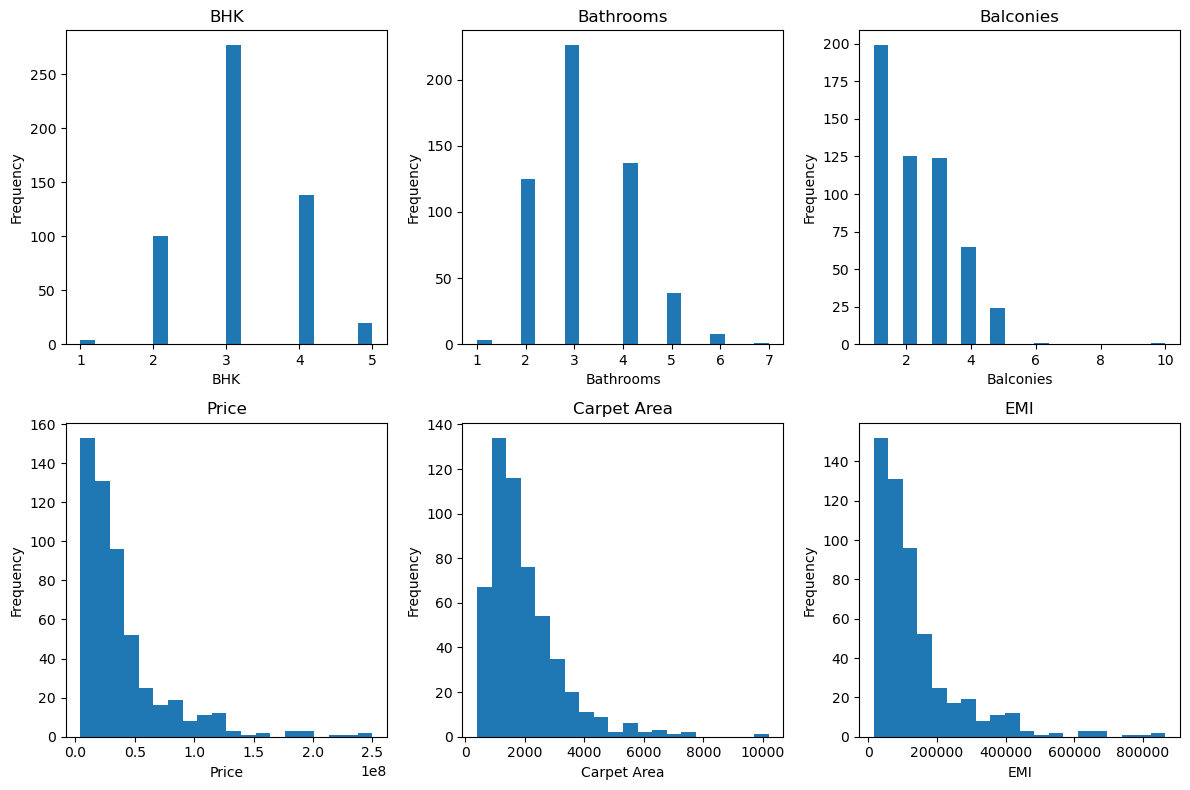

In [38]:
fig,axes=plt.subplots(2,3,figsize=(12,8))
axes=axes.flatten()
for i,col in enumerate(df.select_dtypes(include='number').columns):
    df[col].plot(
        kind='hist',
        ax=axes[i],
        bins=20
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [39]:
df.loc[df['EMI'].idxmax()]

BHK                              4.0
Bathrooms                        4.0
Balconies                        1.0
Price                    250000000.0
Developer              K Raheja Corp
Project        Raheja Modern Vivarea
Carpet Area                   2259.0
Locality                 Mahalakshmi
City                          Mumbai
EMI                         865000.0
Name: 176, dtype: object

In [40]:
df.loc[df['Price'].idxmax()]

BHK                              4.0
Bathrooms                        4.0
Balconies                        1.0
Price                    250000000.0
Developer              K Raheja Corp
Project        Raheja Modern Vivarea
Carpet Area                   2259.0
Locality                 Mahalakshmi
City                          Mumbai
EMI                         865000.0
Name: 176, dtype: object

In [41]:
df.groupby(['City', 'Locality'])['Price'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

,,mean,median
City,Locality,,
Mumbai,Mahalakshmi,1.767000e+08,177300000.0
Gurgaon,Sector 49,1.449250e+08,144500000.0
Mumbai,Juhu,1.436444e+08,121000000.0
Noida,Goberdhanpur,1.126000e+08,112600000.0
Mumbai,Versova,1.007500e+08,100750000.0
...,...,...,...
Hyderabad,Pati,8.950000e+06,8950000.0
Mumbai,Battipada,8.500000e+06,8500000.0
Ahmedabad,Vaishnodevi Circle,7.432500e+06,7400000.0


In [42]:
df['Price_per_sqft'] = df['Price'] / df['Carpet Area']

In [43]:
df[df['Price_per_sqft'] > df['Price_per_sqft'].quantile(0.95)]

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI,Price_per_sqft
100,3.0,3.0,2.0,91000000.0,Kalpataru Limited,Kalpataru Amare,1400.0,Juhu,Mumbai,315000.0,65000.000000
101,5.0,3.0,2.0,240500000.0,Kalpataru Limited,Kalpataru Amare,3700.0,Juhu,Mumbai,833000.0,65000.000000
103,3.0,3.0,1.0,98100000.0,Kalpataru Limited,Kalpataru Amare,1531.0,Juhu,Mumbai,340000.0,64075.767472
104,5.0,3.0,2.0,237200000.0,Kalpataru Limited,Kalpataru Amare,3650.0,Juhu,Mumbai,821000.0,64986.301370
105,4.0,4.0,1.0,121500000.0,Kalpataru Limited,Kalpataru Amare,1845.0,Juhu,Mumbai,421000.0,65853.658537
106,4.0,4.0,1.0,115800000.0,Kalpataru Limited,Kalpataru Amare,1899.0,Juhu,Mumbai,401000.0,60979.462875
107,3.0,3.0,1.0,85700000.0,Kalpataru Limited,Kalpataru Amare,1406.0,Juhu,Mumbai,297000.0,60953.058321
108,4.0,4.0,1.0,121000000.0,Kalpataru Limited,Kalpataru Amare,1845.0,Juhu,Mumbai,419000.0,65582.655827
109,5.0,3.0,2.0,182000000.0,Kalpataru Limited,Kalpataru Amare,2800.0,Juhu,Mumbai,630000.0,65000.000000
170,4.0,4.0,1.0,200400000.0,K Raheja Corp,Raheja Modern Vivarea,2798.0,Mahalakshmi,Mumbai,694000.0,71622.587563


In [44]:
df[df['Price_per_sqft'] < df['Price_per_sqft'].quantile(0.01)]

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI,Price_per_sqft
328,4.0,4.0,1.0,12700000.0,HR Group,HR Eliseo,2825.0,Shela,Ahmedabad,44000.0,4495.575221
330,3.0,3.0,1.0,8000000.0,Redbricks Infra,Royal Opulence,1800.0,Vaishnodevi Circle,Ahmedabad,28000.0,4444.444444
331,3.0,3.0,1.0,7300000.0,Redbricks Infra,Royal Opulence,1800.0,Vaishnodevi Circle,Ahmedabad,25000.0,4055.555556
332,3.0,3.0,1.0,7500000.0,Redbricks Infra,Royal Opulence,1800.0,Vaishnodevi Circle,Ahmedabad,26000.0,4166.666667
386,3.0,3.0,2.0,6690000.0,Vishwanath Builders,Vishwanath Sarathya West,1760.0,Shela,Ahmedabad,23000.0,3801.136364
472,2.0,2.0,3.0,4300000.0,Galaxy Group,Galaxy North Avenue 2,1175.0,Gaur City 2,Noida,15000.0,3659.574468


### Outlier Analysis Conclusion
1. The outlier analysis was conducted on key numerical features such as Price, EMI, Carpet Area, and Price per square foot (Price_per_sqft) to identify any abnormal or inconsistent data points.

2. Instead of relying solely on raw values, a derived feature — Price_per_sqft — was used as the primary metric, as it provides a more meaningful comparison across properties of varying sizes and locations.

3. The analysis revealed that most extreme values in Price and Area were not true outliers but rather reflected genuine variations in property types, such as luxury homes, large villas, or properties in premium locations. These values showed consistent relationships when normalized using Price_per_sqft.

4. Overall, the dataset retains its natural variability, including high-end and low-end properties, ensuring that important market segments are preserved.

# Exploratory Data Analysis

### 1.Univariate Data Analysis

### Univariate Data Analysis for Categorical Data

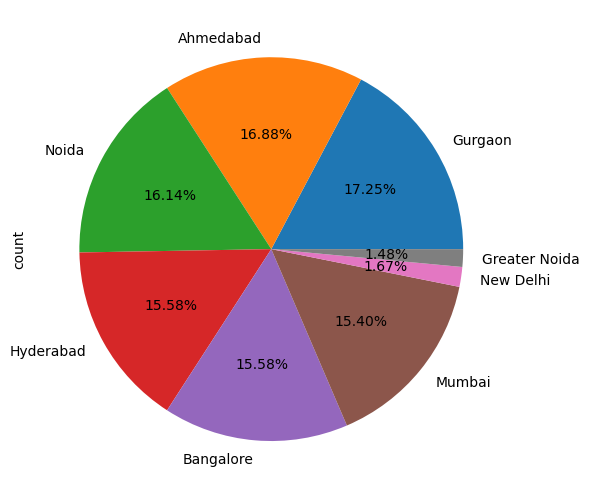

In [45]:
df['City'].value_counts().plot(kind='pie',autopct='%1.2f%%',figsize=(6,6))
plt.tight_layout()

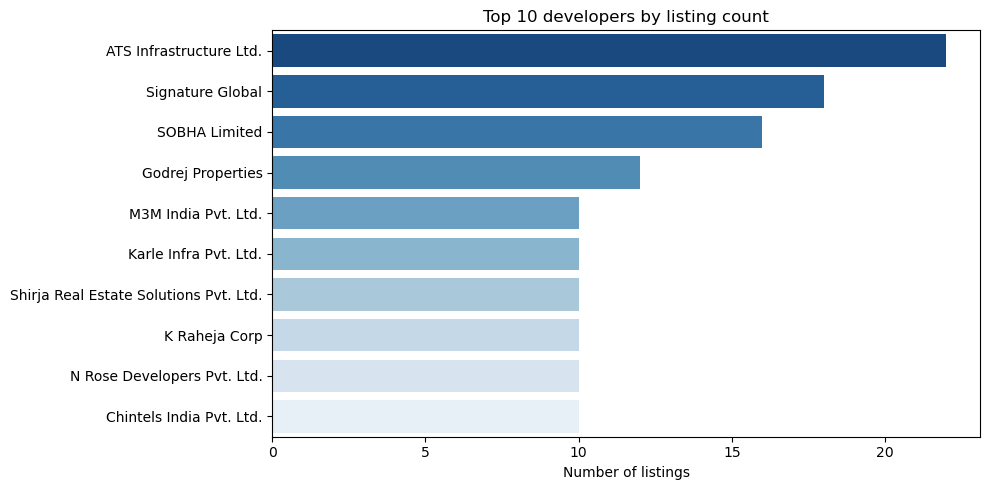

In [46]:
plt.figure(figsize=(10, 5))
top_devs = df['Developer'].value_counts().head(10)
sns.barplot(x=top_devs.values, y=top_devs.index, palette='Blues_r')
plt.title('Top 10 developers by listing count')
plt.xlabel('Number of listings')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Univariate Data Analysis for Numerical Data

### Box Plot per city

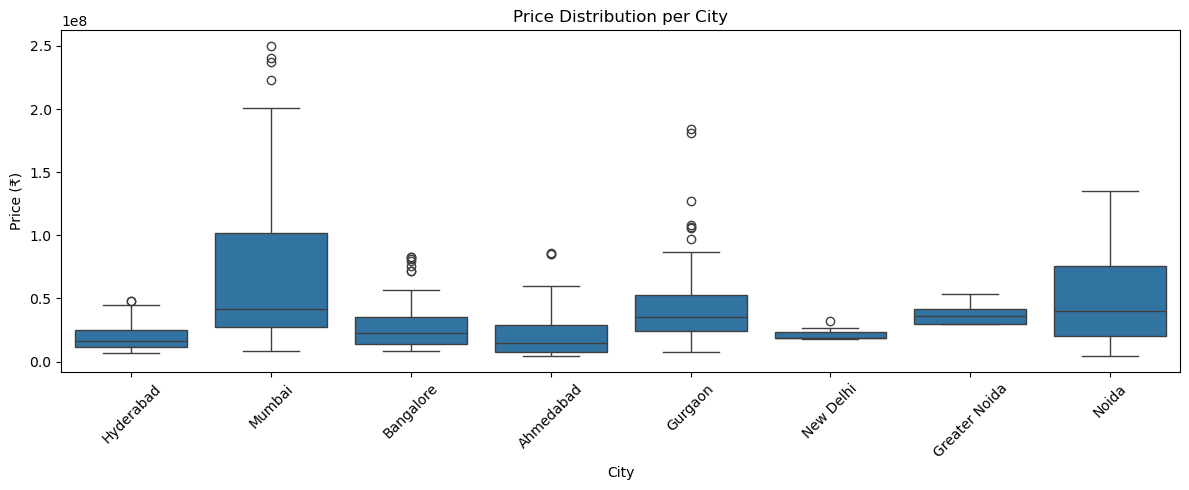

In [47]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='City', y='Price')
plt.title('Price Distribution per City')
plt.xticks(rotation=45)
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

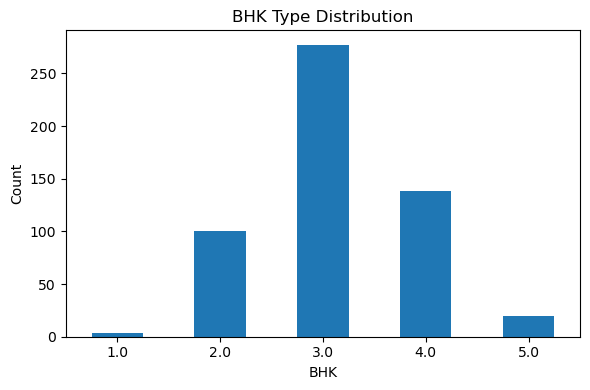

In [48]:
plt.figure(figsize=(6,4))
df['BHK'].value_counts().sort_index().plot(kind='bar')
plt.title('BHK Type Distribution')
plt.xlabel('BHK')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

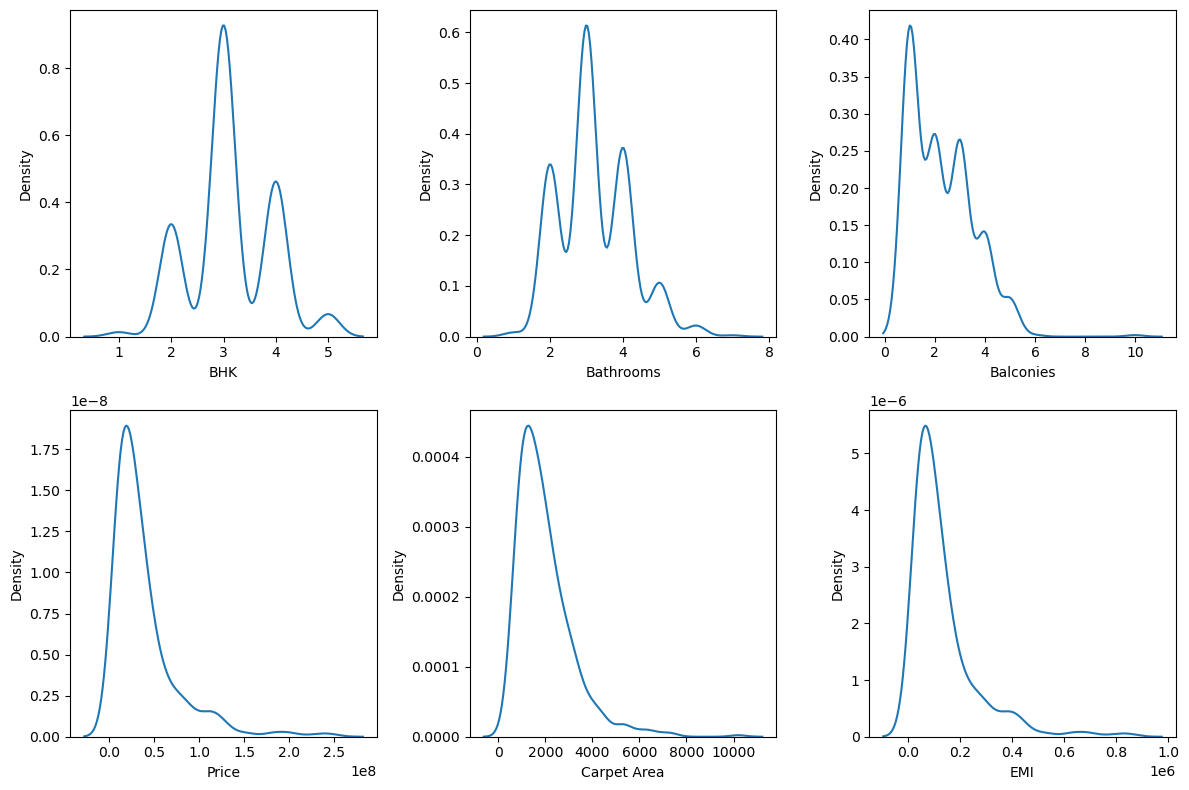

In [49]:
fig,axes=plt.subplots(2,3,figsize=(12,8))
axes=axes.flatten()
numeric_cols=df.select_dtypes(include='number').columns
for i,col in enumerate(numeric_cols[:6]):
    sns.kdeplot(df[col],ax=axes[i])
plt.tight_layout()
plt.show()

### Bivariate Data Analysis for Numerical vs Numerical Data

In [50]:
corr_matrix_num=df.corr(numeric_only=True)
corr_matrix_num

,BHK,Bathrooms,Balconies,Price,Carpet Area,EMI,Price_per_sqft
BHK,1.000000,0.829217,0.330431,0.553935,0.716512,0.558903,0.148272
Bathrooms,0.829217,1.000000,0.382619,0.494553,0.629400,0.497250,0.169243
Balconies,0.330431,0.382619,1.000000,0.259745,0.397482,0.257885,-0.039874
Price,0.553935,0.494553,0.259745,1.000000,0.533861,0.998966,0.753722
Carpet Area,0.716512,0.629400,0.397482,0.533861,1.000000,0.542454,-0.035886
EMI,0.558903,0.497250,0.257885,0.998966,0.542454,1.000000,0.750876
Price_per_sqft,0.148272,0.169243,-0.039874,0.753722,-0.035886,0.750876,1.000000


In [51]:
corr_matrix_num['Price'].sort_values(ascending=False)

Price             1.000000
EMI               0.998966
Price_per_sqft    0.753722
BHK               0.553935
Carpet Area       0.533861
Bathrooms         0.494553
Balconies         0.259745
Name: Price, dtype: float64

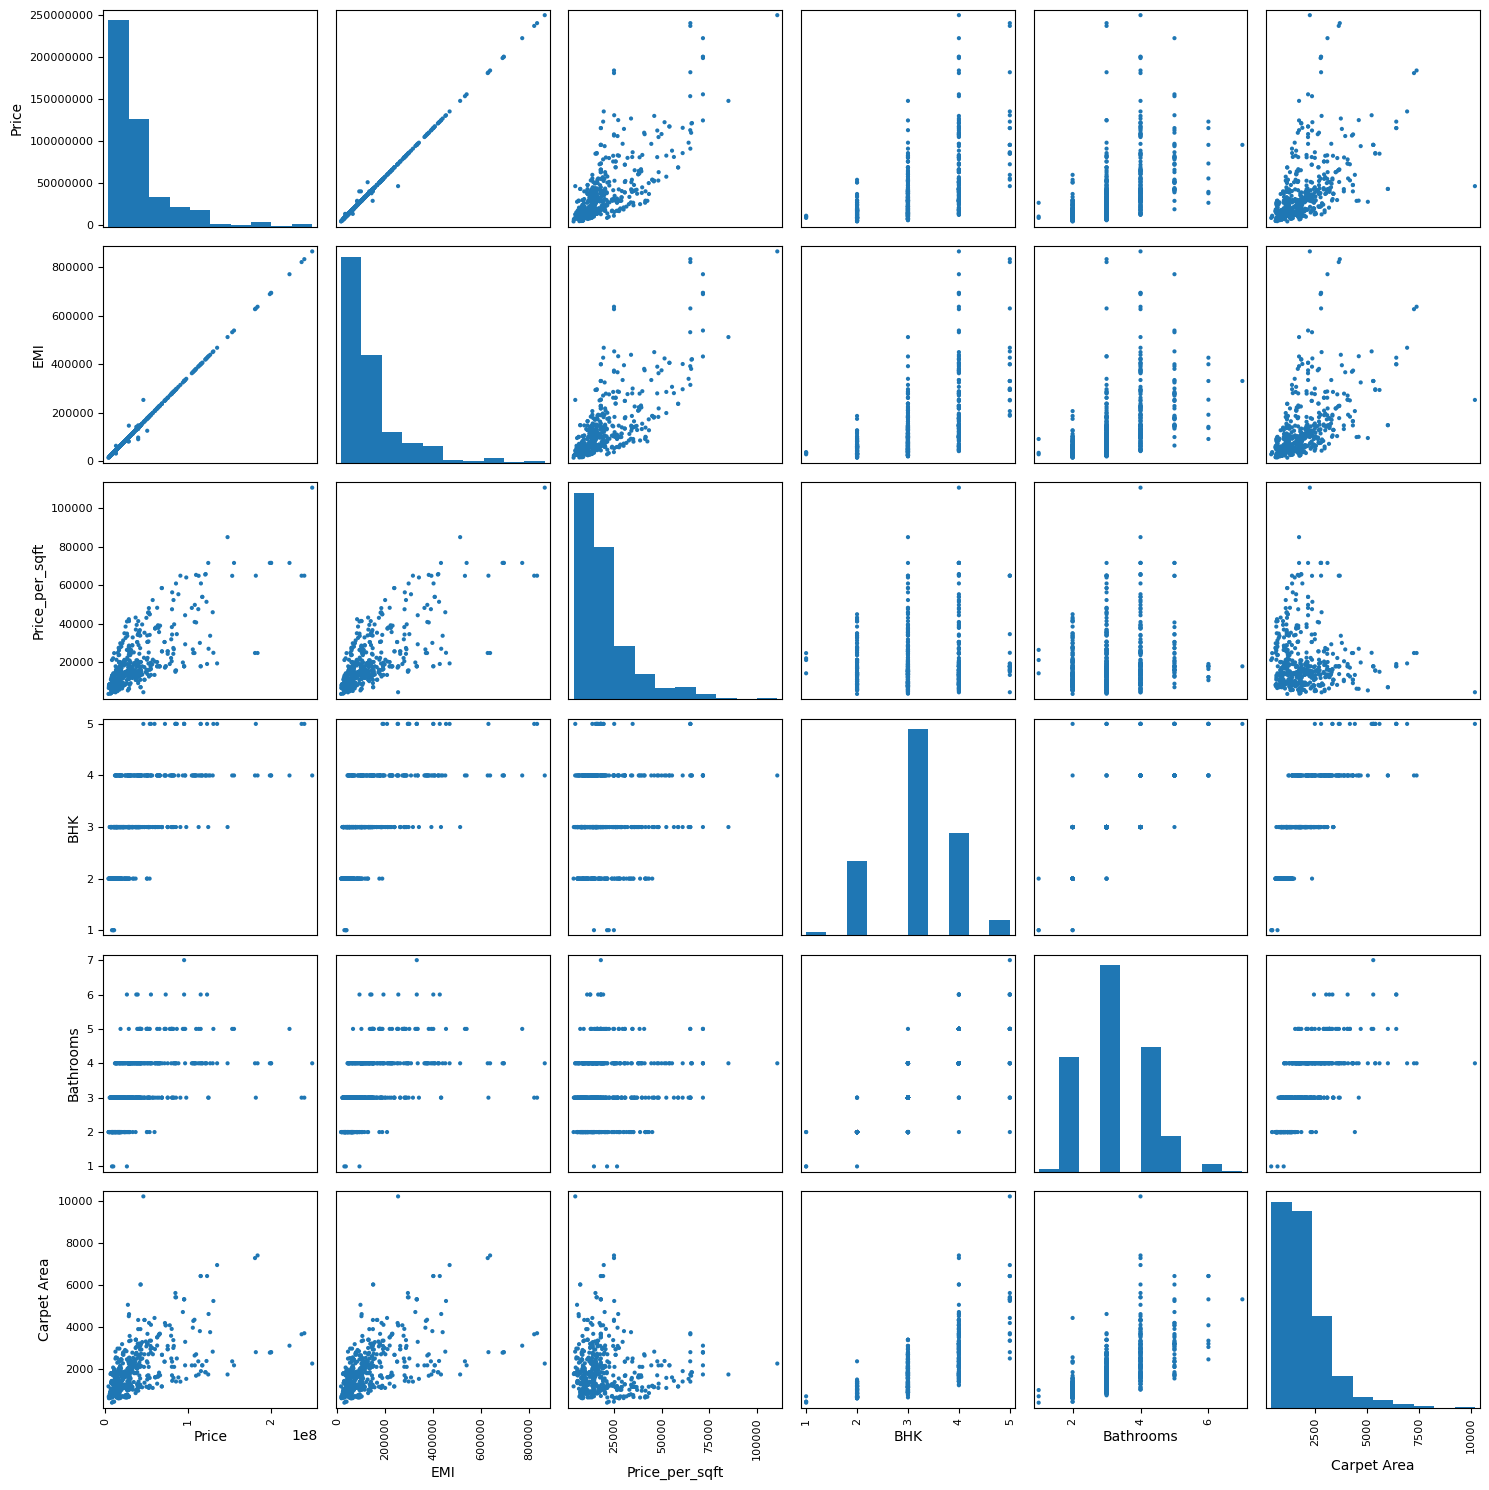

In [52]:
from pandas.plotting import scatter_matrix
promising_attr=['Price','EMI','Price_per_sqft','BHK','Bathrooms','Carpet Area']
scatter_matrix(df[promising_attr],figsize=(15,15),alpha=1)
plt.tight_layout()
plt.show()

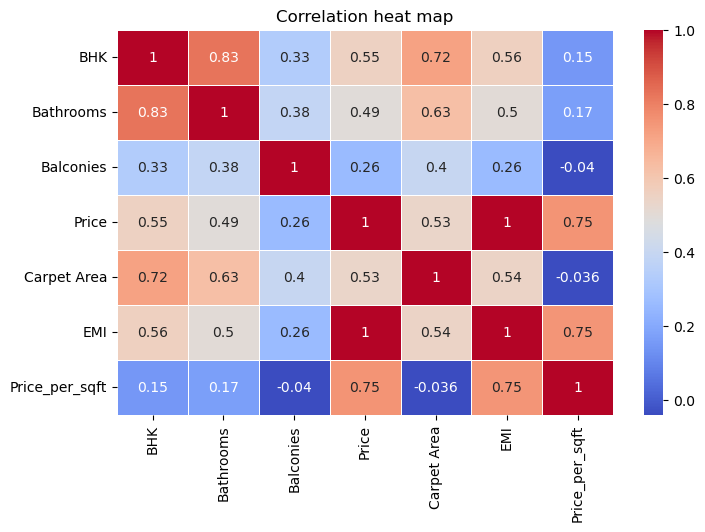

In [53]:
plt.figure(figsize=(8,5))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation heat map')
plt.show()

### Bivariate Analysis for Numerical vs Categorical Data

In [54]:
df.groupby('City')['Price_per_sqft'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)

,mean,median,count
City,,,
Mumbai,44848.684505,41443.298969,83
Gurgaon,20277.253183,18200.000000,93
New Delhi,18296.127946,17000.000000,9
Noida,19418.653225,16417.910448,87
Bangalore,17186.091431,14998.961363,84
Greater Noida,17293.907985,13112.718341,8
Hyderabad,9369.743594,8636.467735,84
Ahmedabad,9658.830444,8607.198748,91


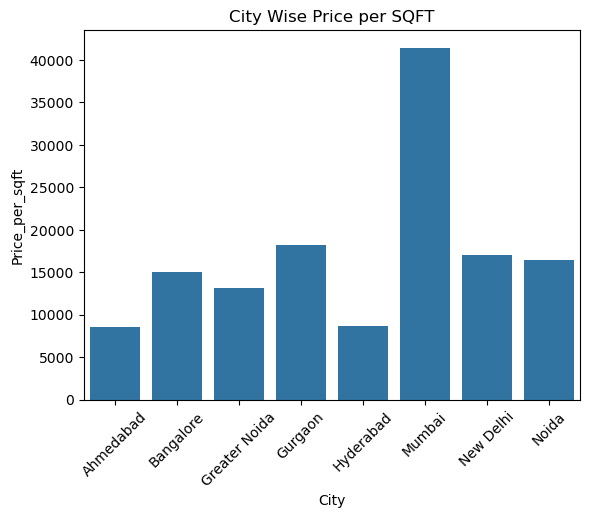

In [55]:
city_data = df.groupby('City')['Price_per_sqft'].median().reset_index()
sns.barplot(data=city_data, x='City', y='Price_per_sqft')
plt.title('City Wise Price per SQFT')
plt.xticks(rotation=45)
plt.show()

In [56]:
df.groupby(['City', 'Locality'])['Price_per_sqft']\
  .median()\
  .sort_values(ascending=False)

City       Locality          
Mumbai     Mahalakshmi           71622.104592
           Juhu                  65000.000000
           Central Area          56358.582349
           Andheri               54001.839926
           Powai                 52369.278600
                                     ...     
Ahmedabad  Chharodi               5912.698413
Gurgaon    Garauli Khurd          5899.705015
Hyderabad  Patancheru             5753.138075
Ahmedabad  Vaishnodevi Circle     4305.555556
Noida      Gaur City 2            3659.574468
Name: Price_per_sqft, Length: 90, dtype: float64

# Locality wise per city price per sqft

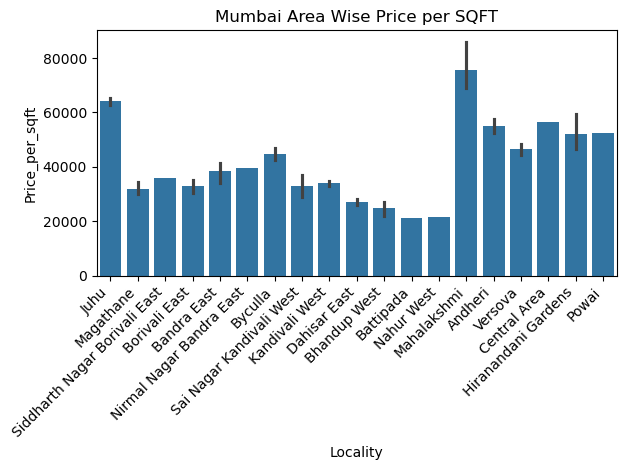

<Figure size 1000x2000 with 0 Axes>

In [57]:
sns.barplot(
    data=df[df['City'] == 'Mumbai'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Mumbai Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

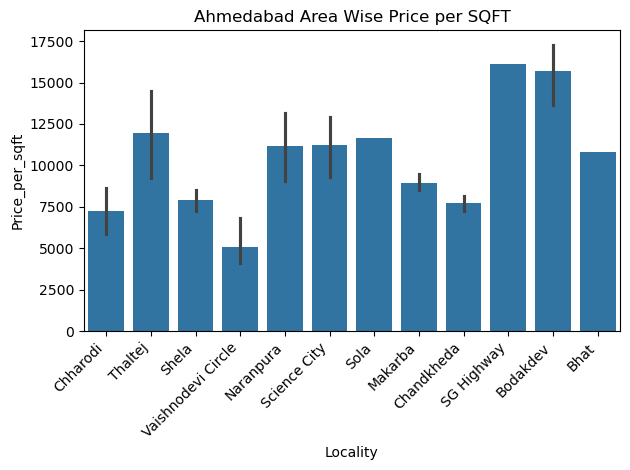

<Figure size 1000x2000 with 0 Axes>

In [58]:
sns.barplot(
    data=df[df['City'] == 'Ahmedabad'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Ahmedabad Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

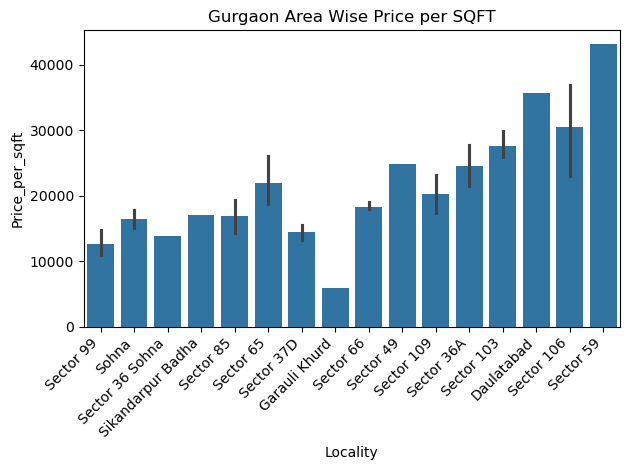

<Figure size 1000x2000 with 0 Axes>

In [59]:
sns.barplot(
    data=df[df['City'] == 'Gurgaon'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Gurgaon Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

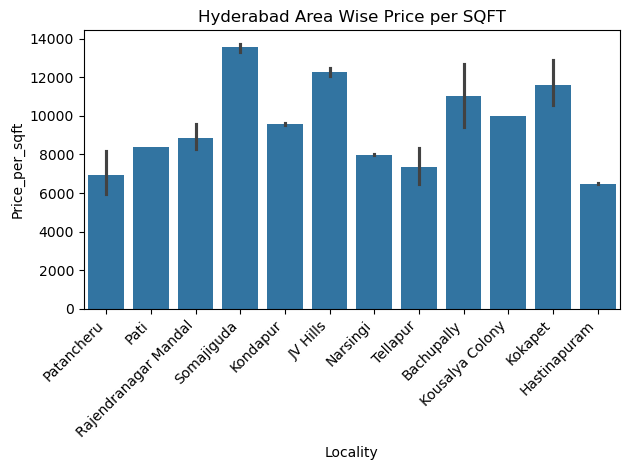

<Figure size 1000x2000 with 0 Axes>

In [60]:
sns.barplot(
    data=df[df['City'] == 'Hyderabad'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Hyderabad Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

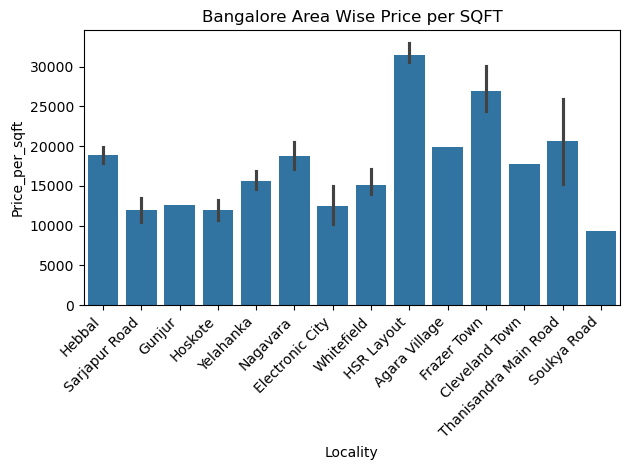

<Figure size 1000x2000 with 0 Axes>

In [61]:
sns.barplot(
    data=df[df['City'] == 'Bangalore'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Bangalore Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

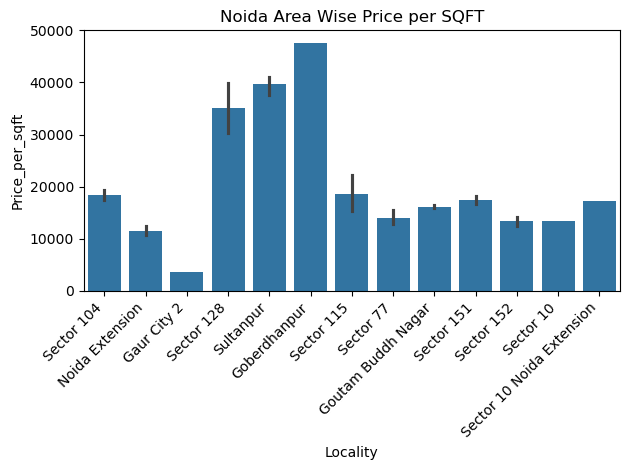

<Figure size 1000x2000 with 0 Axes>

In [62]:
sns.barplot(
    data=df[df['City'] =='Noida'],  # change city
    x='Locality',
    y='Price_per_sqft'
)
plt.title('Noida Area Wise Price per SQFT')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.figure(figsize=(10,20))
plt.show()

# Price vs Carpet Area (hue = BHK) scatter plot

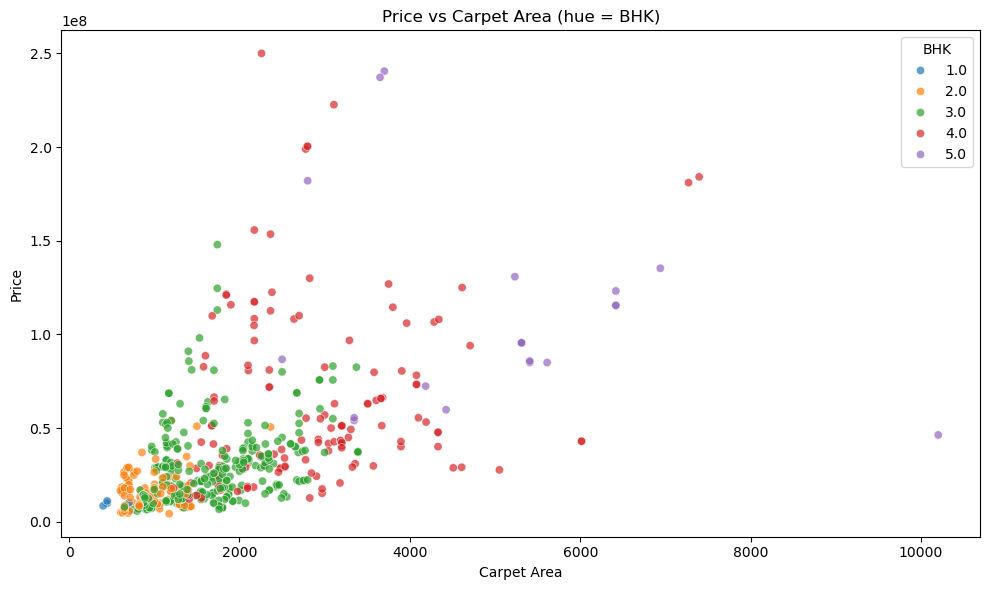

In [63]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Carpet Area', y='Price', hue='BHK', palette='tab10', alpha=0.7)
plt.title('Price vs Carpet Area (hue = BHK)')
plt.tight_layout()
plt.show()

# Multivariate Analysis

In [64]:
df['Carpet_to_bhk']=df['Carpet Area']/df['BHK']
df['Carpet_to_bath']=df['Carpet Area']/df['Bathrooms']

In [65]:
df

,BHK,Bathrooms,Balconies,Price,Developer,Project,Carpet Area,Locality,City,EMI,Price_per_sqft,Carpet_to_bhk,Carpet_to_bath
0,3.0,2.0,1.0,9740000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1265.0,Patancheru,Hyderabad,34000.0,7699.604743,421.666667,632.500000
2,3.0,2.0,1.0,12200000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1585.0,Patancheru,Hyderabad,42000.0,7697.160883,528.333333,792.500000
3,2.0,2.0,1.0,9000000.0,Ramky Estates & Farms Limited,Ramky One Symphony,674.0,Patancheru,Hyderabad,31000.0,13353.115727,337.000000,337.000000
5,2.0,2.0,1.0,8950000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1065.0,Pati,Hyderabad,31000.0,8403.755869,532.500000,532.500000
6,2.0,2.0,1.0,6900000.0,Ramky Estates & Farms Limited,Ramky One Symphony,1063.0,Patancheru,Hyderabad,24000.0,6491.063029,531.500000,531.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691,4.0,4.0,4.0,66500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,230000.0,39071.680376,425.500000,425.500000
694,3.0,4.0,3.0,52500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2700.0,Sector 106,Gurgaon,182000.0,19444.444444,900.000000,675.000000
695,4.0,4.0,4.0,64500000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,1702.0,Sector 106,Gurgaon,223000.0,37896.592244,425.500000,425.500000
697,5.0,5.0,3.0,86700000.0,Elan Buildcon Pvt. Ltd.,Elan The Presidential,2500.0,Sector 106,Gurgaon,300000.0,34680.000000,500.000000,500.000000


In [66]:
df_corr_compare=df[['Price','Carpet_to_bhk','Carpet_to_bath']].corr()
df_corr_compare['Price'].sort_values(ascending=False)

Price             1.000000
Carpet_to_bhk     0.411360
Carpet_to_bath    0.373058
Name: Price, dtype: float64

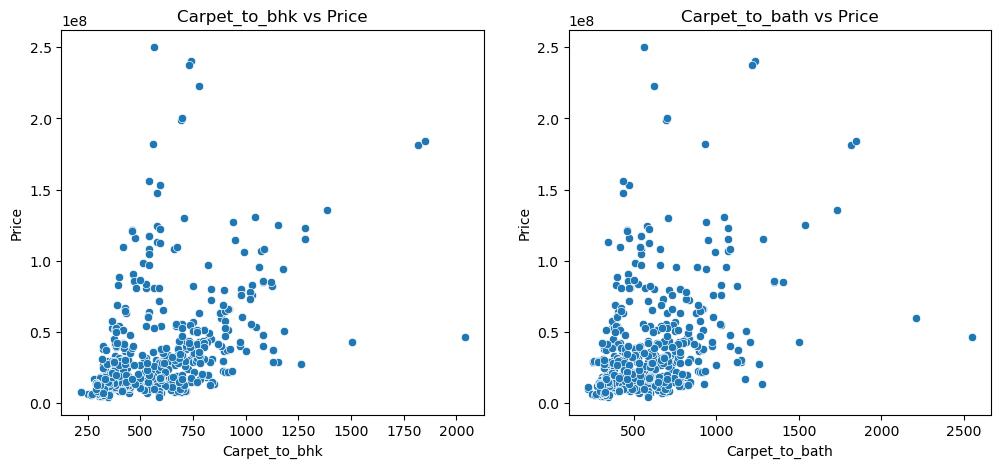

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=df, x='Carpet_to_bhk', y='Price', ax=axes[0])
axes[0].set_title('Carpet_to_bhk vs Price')

sns.scatterplot(data=df, x='Carpet_to_bath', y='Price', ax=axes[1])
axes[1].set_title('Carpet_to_bath vs Price')

plt.show()

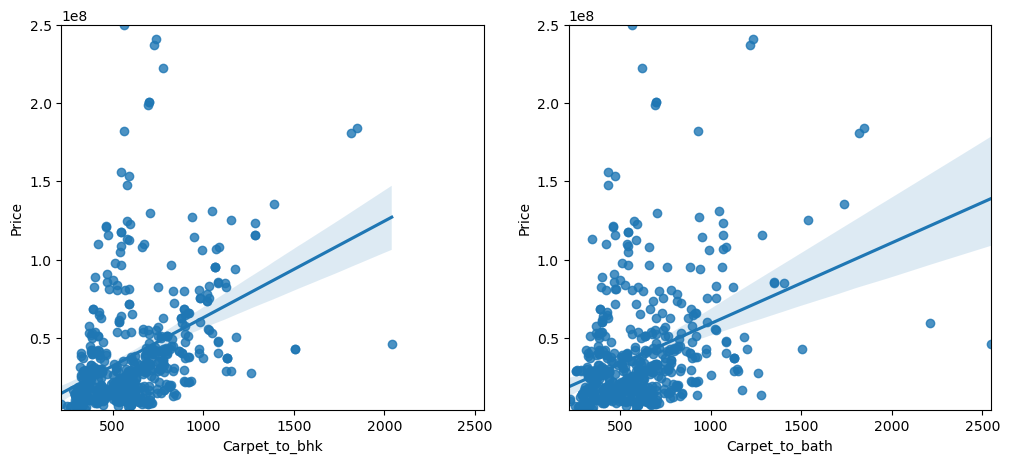

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Plot
sns.regplot(data=df, x='Carpet_to_bhk', y='Price', ax=axes[0])
sns.regplot(data=df, x='Carpet_to_bath', y='Price', ax=axes[1])

# Get common limits
x_min = min(df['Carpet_to_bhk'].min(), df['Carpet_to_bath'].min())
x_max = max(df['Carpet_to_bhk'].max(), df['Carpet_to_bath'].max())

y_min = df['Price'].min()
y_max = df['Price'].max()

# Apply same limits
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.show()

# City vs EMI vs price_per_sqft

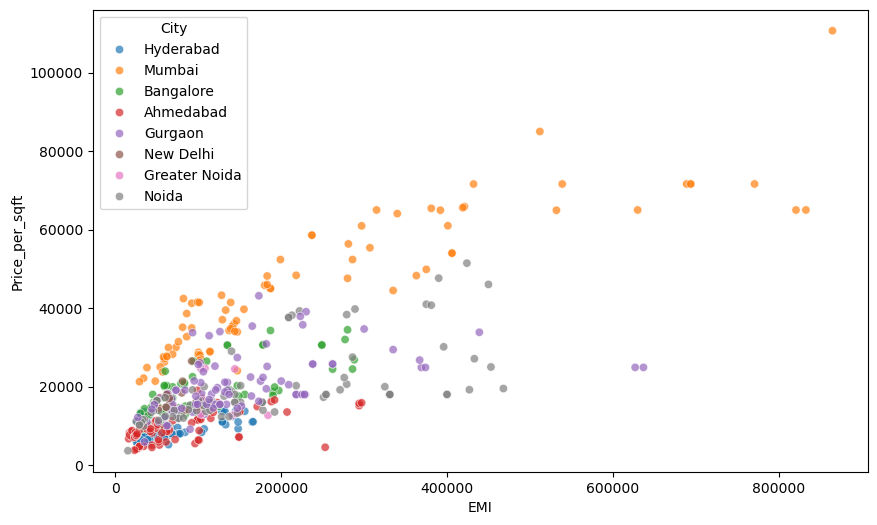

In [69]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='EMI',
    y='Price_per_sqft',
    hue='City',
    alpha=0.7
)

plt.show()

# Top Localities per city vs EMI vs price_per_sqft

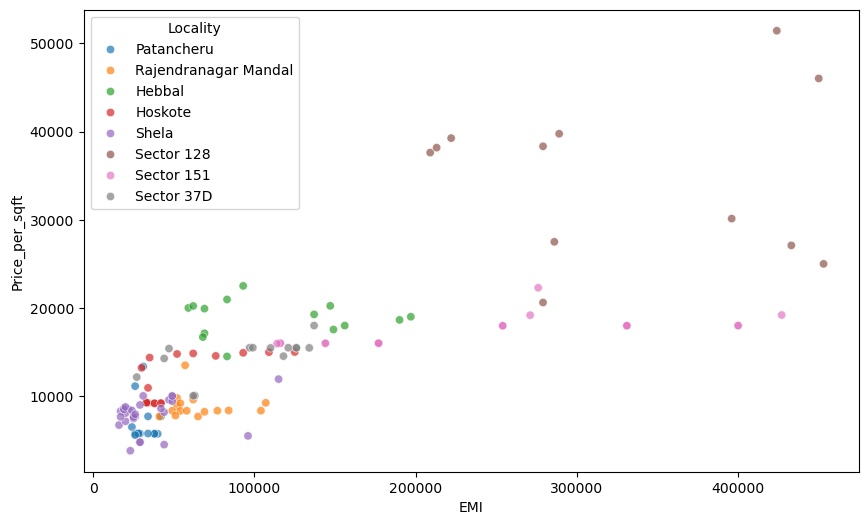

In [70]:
top_localities = df['Locality'].value_counts().head(8).index

filtered = df[df['Locality'].isin(top_localities)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered,
    x='EMI',
    y='Price_per_sqft',
    hue='Locality',
    alpha=0.7
)

plt.show()

# Bubble Plot for EMI vs Price_per_sqft vs City vs Carpet Area

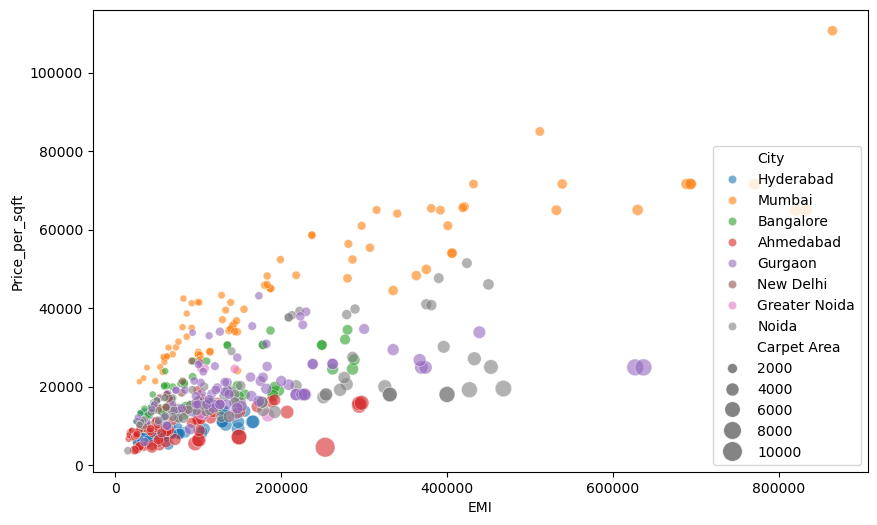

In [71]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='EMI',
    y='Price_per_sqft',
    hue='City',
    size='Carpet Area',
    sizes=(20, 200),
    alpha=0.6
)

plt.show()

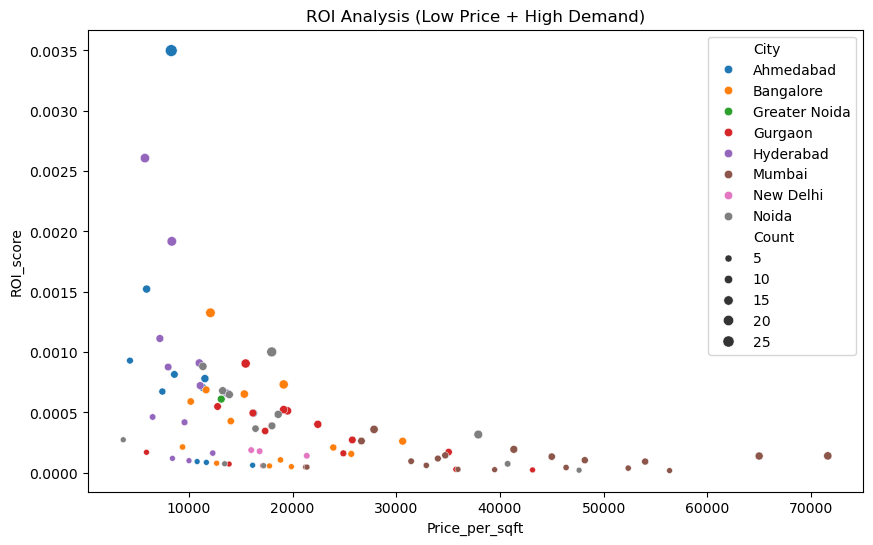

In [72]:
locality_stats = df.groupby(['City', 'Locality']).agg({
    'Price_per_sqft': 'median',
    'EMI': 'median',
    'Price': 'count'
}).rename(columns={'Price': 'Count'}).reset_index()
locality_stats['ROI_score'] = (
    locality_stats['Count'] / locality_stats['Price_per_sqft']
)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=locality_stats,
    x='Price_per_sqft',
    y='ROI_score',
    hue='City',
    size='Count'
)
plt.title('ROI Analysis (Low Price + High Demand)')
plt.show()

# Pivot Tables

In [73]:
affordable = df.pivot_table(
    index='City',
    values=['Price', 'Price_per_sqft', 'EMI'],
    aggfunc={'Price': 'median', 'Price_per_sqft': 'median', 'EMI': 'median'}
).sort_values('Price_per_sqft')
affordable['Affordability_rank'] = range(1, len(affordable)+1)

In [74]:
affordable

,EMI,Price,Price_per_sqft,Affordability_rank
City,,,,
Ahmedabad,52000.0,14900000.0,8607.198748,1
Hyderabad,57500.0,16500000.0,8636.467735,2
Greater Noida,124500.0,35950000.0,13112.718341,3
Bangalore,77500.0,22450000.0,14998.961363,4
Noida,138000.0,40000000.0,16417.910448,5
New Delhi,66000.0,19000000.0,17000.000000,6
Gurgaon,121000.0,35000000.0,18200.000000,7
Mumbai,146000.0,41500000.0,41443.298969,8


In [75]:
local_pivot = df.pivot_table(
    index=['City', 'Locality'],
    values=['Price_per_sqft', 'Price', 'EMI'],
    aggfunc='median'
).reset_index().sort_values(['City', 'Price_per_sqft'])

In [76]:
local_pivot

,City,Locality,EMI,Price,Price_per_sqft
11,Ahmedabad,Vaishnodevi Circle,25500.0,7400000.0,4305.555556
3,Ahmedabad,Chharodi,44000.0,12700000.0,5912.698413
2,Ahmedabad,Chandkheda,24000.0,6800000.0,7431.693989
8,Ahmedabad,Shela,26000.0,7390000.0,8289.473684
4,Ahmedabad,Makarba,62000.0,18000000.0,8591.885442
...,...,...,...,...,...
84,Noida,Sector 115,144000.0,41500000.0,18012.152778
83,Noida,Sector 104,138000.0,40000000.0,18604.651163
85,Noida,Sector 128,287500.0,83000000.0,37904.228856
89,Noida,Sultanpur,375000.0,108200000.0,40740.740741


In [77]:
bhk_pivot = df.pivot_table(
    index='City', columns='BHK',
    values='Price_per_sqft', aggfunc='median'
).round(0)

In [78]:
bhk_pivot

BHK,1.0,2.0,3.0,4.0,5.0
City,,,,,
Ahmedabad,NaN,8378.0,7634.0,10007.0,15720.0
Bangalore,14367.0,14559.0,15235.0,25237.0,NaN
Greater Noida,NaN,NaN,13100.0,13125.0,NaN
Gurgaon,NaN,19112.0,17593.0,18991.0,34680.0
Hyderabad,NaN,7197.0,8338.0,10991.0,NaN
Mumbai,22148.0,30000.0,39592.0,65174.0,65000.0
New Delhi,NaN,18000.0,16409.0,NaN,NaN
Noida,NaN,11039.0,15956.0,20097.0,17999.0


In [79]:
dev_pivot = df.pivot_table(
    index='Developer',
    values=['Price_per_sqft', 'Carpet Area', 'Price'],
    aggfunc={'Price_per_sqft': 'median', 'Carpet Area': 'mean', 'Price': 'count'}
).rename(columns={'Price': 'Listings'}).sort_values('Price_per_sqft', ascending=False).head(15)

###  Developer quality index (price per sqft + avg carpet area — signals premium vs budget)

In [80]:
dev_pivot

,Carpet Area,Listings,Price_per_sqft
Developer,,,
K Raheja Corp,2349.800000,10,71622.104592
Kalpataru Limited,2230.666667,9,65000.000000
Ajmera Realty & Infra India Ltd. and Sheetal Infrastructure Pvt. Ltd.,1887.000000,7,54001.839926
Hiranandani Group,1347.875000,8,52369.278600
Marathon Realty & Adani Group,1231.166667,6,44995.826377
Conscient and Hines,1159.000000,1,43140.638481
Raymond Realty,849.555556,9,41240.310078
Max Estates 128 Private Limited,3319.250000,8,40862.794613
Kalpataru Ltd.,2195.500000,8,37904.228856


# Overall project Conclusion

### Univariate analysis conclusion
1. The dataset after cleaning has 466 unique records across 8 cities.

2. BHK is dominated by 3-BHK configurations (~50%), followed by 2-BHK. Price and EMI distributions are heavily right-skewed — the median price (₹2.8 Cr) is far below the mean (₹3.73 Cr), confirming that a small number of luxury listings in Mumbai and Gurgaon pull the average up.

3. Carpet area is approximately normally distributed around 1,700 sq ft.

### Bivariate analysis conclusion
1. EMI and Price are nearly perfectly correlated (r = 0.999), so EMI adds no independent signal — one of them can be dropped for Exploratory Data Analysis.

2.  BHK is the next strongest predictor (r = 0.54 with Price), followed by Bathrooms and Carpet Area.

3.  The city-wise Price_per_sqft analysis reveals a massive gap: Mumbai (₹41,488/sqft median) is roughly 5x more expensive than Hyderabad (₹8,368/sqft) and Ahmedabad (₹8,592/sqft), showing that location is the dominant pricing factor, not size or configuration.

### Multivariate analysis conclusion
1. The derived features Carpet_to_bhk (r = 0.36) and Carpet_to_bath (r = 0.29) have weaker correlations with Price than raw Carpet Area (r = 0.49), so the ratios don't improve signal.

2. The City × EMI × Price_per_sqft scatter clearly shows Mumbai forming its own cluster at high EMI and high sqft price, while Hyderabad and Ahmedabad cluster at the affordable bottom-left.

3.  The ROI scatter confirms Ahmedabad and Hyderabad as high-demand, low-price-per-sqft markets — the best candidates for investment value plays
### Overall project conclusion
1. This project successfully scraped 700 listings across 7 Indian metro markets, cleaned mixed-format price/area/EMI strings, engineered a meaningful Price_per_sqft feature, and performed a full EDA pyramid.
2. Key findings:
   1. Mumbai is in a league of its own on per-sqft pricing
   2. Ahmedabad and Hyderabad offer the best affordability-to-demand ratio
   3. 3-BHK is the dominant product type across all cities